# real_groundtruth_downscale.ipynb

Real-data analogue of the paper's controlled synthetic-detector experiment
(Esri World Imagery, Table I): same structure, but using only real
Sentinel-2 data. All function definitions live in
`tests/real_groundtruth_common_tools.py` (imported below as `gt`) -- this
notebook is deliberately just calls and inline inspection of intermediate
results, step by step.

**Protocol** (see the module's own docstring for the full rationale and
revision history):

1. fetch a real, native 10 m Sentinel-2 B04 UTM patch
2. PSF-aware resample the real (undegraded) data to `gt.NATIVE_LEVEL` (20)
3. plain (no-PSF) NESTED downgrade to `gt.REF_LEVEL` (17) -- **the reference**
4. Gaussian-blur the real data to the coarse effective resolution
5. point-sample (decimate) every `gt.BLOCK`-th pixel (not a block average)
6. PSF-aware resample the coarse samples directly onto `gt.REF_LEVEL`
7. compare against the reference, cell-for-cell, at `gt.REF_LEVEL`

**Changing parameters**: edit the constants in `real_groundtruth_common_tools.py`,
or override them from here before calling a function, e.g. `gt.REF_LEVEL = 17`
-- both work because every function reads its configuration from the
module's own globals at call time (see the module docstring for why this
requires `import ... as gt`, not `from ... import *`).

In [ ]:
# PAPER_DATA_OFFLINE_GUARD
# Publication notebooks never contact mutable remote services. Run
# load_data_in_zenodo.ipynb once if this check reports missing frozen inputs.
OFFLINE = True
try:
    from paper_data_guard import require_paper_data
except ModuleNotFoundError:
    from notebooks.paper_data_guard import require_paper_data

REPO_ROOT = require_paper_data("real_groundtruth_downscale.ipynb")


## Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward from `start` (default: this notebook's cwd) until a
    directory containing `marker` (the package's own source tree) is found.
    More robust than a hardcoded `..` -- works regardless of whether the
    notebook is actually run with cwd=notebooks/ or something else, and
    sidesteps any ambiguity about where the repo root is."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root (looked for a '{marker}' directory above {p}).")

REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("repo root:  ", REPO_ROOT)
print("module path:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

# Loaded directly from its file path (importlib.util), NOT via
# `import tests.real_groundtruth_common_tools`: a plain dotted import
# depends on `tests` resolving, on sys.path, to *this* directory -- but
# `tests` is a common, generic top-level name, and if anything else on
# sys.path (another package, another checkout of this repo, a stray
# editable-install path) also happens to expose a `tests` package or
# namespace, Python can silently bind `tests` to that other one instead,
# producing exactly "No module named 'tests.real_groundtruth_common_tools'"
# (tests found, submodule not found in it) rather than a clean, obvious
# "tests not found". Loading straight from MODULE_PATH sidesteps that
# entirely: there is no package-name resolution involved, so no ambiguity.
spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()

repo root:   /home/jovyan/healpix-resample
module path: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 1 -- fetch real native 10 m patches

Shared cache with `test-resample-paper.ipynb` (`notebooks/data/{scene}_data.zarr`) -- reused if already present.

In [2]:
for scene in gt.benchmark_coordinates:
    gt.extract_bench_data(scene)


[urban] cached  <- S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135  (2026-05-27T10:56:19.024000Z, cloud 0.00289%)
[water] cached  <- S2A_MSIL2A_20260624T103041_N0512_R108_T32TLS_20260624T182910  (2026-06-24T10:30:41.024000Z, cloud 2.696484%)
[forest] cached  <- S2A_MSIL2A_20260724T102701_N0512_R108_T32UMU_20260724T171410  (2026-07-24T10:27:01.024000Z, cloud 0.078397%)
[agriculture] cached  <- S2A_MSIL2A_20260623T105711_N0512_R094_T31UCP_20260623T173411  (2026-06-23T10:57:11.024000Z, cloud 1.064157%)


## Steps 2-3 -- build the reference (real data, no degradation)

Inspect: number of retained cells and value range at `NATIVE_LEVEL`, then after the downgrade to `REF_LEVEL`.

In [3]:
refs = {scene: gt.build_reference(scene) for scene in gt.benchmark_coordinates}

for scene, ref in refs.items():
    n_native = len(ref["cell_ids_native"])
    n_ref = len(ref["cell_ids_ref"])
    print(f"{scene:12s}  level {gt.NATIVE_LEVEL}: {n_native:7d} cells "
          f"[{ref['cell_data_native'].min():.4f}, {ref['cell_data_native'].max():.4f}]"
          f"   ->  level {gt.REF_LEVEL}: {n_ref:6d} cells "
          f"[{ref['cell_data_ref'].min():.4f}, {ref['cell_data_ref'].max():.4f}]")


urban         level 20:  171534 cells [-0.5496, 2.5264]   ->  level 19:  42996 cells [-0.3720, 2.0846]
water         level 20:  171403 cells [-0.1122, 0.7850]   ->  level 19:  42950 cells [-0.0120, 0.5335]
forest        level 20:  171521 cells [-0.0733, 0.4358]   ->  level 19:  42978 cells [-0.0056, 0.3519]
agriculture   level 20:  171493 cells [-0.0096, 0.4043]   ->  level 19:  42988 cells [0.0111, 0.3872]


Quick look: histogram of the reference values for one scene.

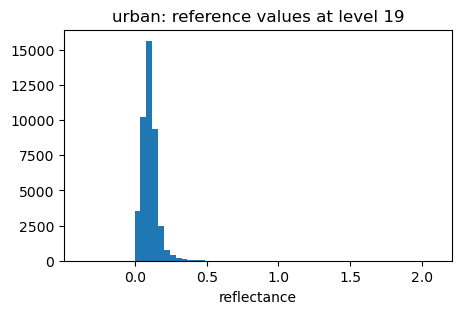

In [4]:
scene = "urban"
plt.figure(figsize=(5, 3))
plt.hist(refs[scene]["cell_data_ref"], bins=60)
plt.title(f"{scene}: reference values at level {gt.REF_LEVEL}")
plt.xlabel("reflectance")
plt.show()


## Steps 4-5 -- degrade to coarse UTM samples

Inspect: coarse image shape and value range per scene, then a quick side-by-side of native vs. degraded for one scene.

In [5]:
coarse = {scene: gt.build_coarse_grid(scene) for scene in gt.benchmark_coordinates}

for scene, g in coarse.items():
    print(f"{scene:12s}  native {g['img_native'].shape}  ->  coarse {g['img_coarse'].shape}"
          f"   coarse range [{g['img_coarse'].min():.4f}, {g['img_coarse'].max():.4f}]")


urban         native (256, 256)  ->  coarse (128, 128)   coarse range [0.0126, 1.0267]
water         native (256, 256)  ->  coarse (128, 128)   coarse range [0.0074, 0.2943]
forest        native (256, 256)  ->  coarse (128, 128)   coarse range [0.0107, 0.2507]
agriculture   native (256, 256)  ->  coarse (128, 128)   coarse range [0.0156, 0.3676]


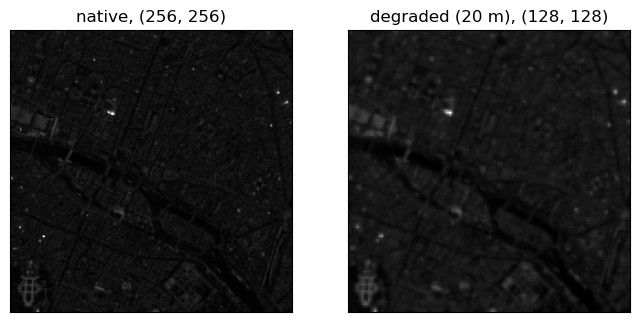

In [6]:
scene = "urban"
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(coarse[scene]["img_native"], cmap="gray")
axes[0].set_title(f"native, {coarse[scene]['img_native'].shape}")
axes[1].imshow(coarse[scene]["img_coarse"], cmap="gray")
axes[1].set_title(f"degraded ({gt.PIXEL_SIZE_COARSE_M:.0f} m), {coarse[scene]['img_coarse'].shape}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()


## Step 6 -- PSF-aware reconstruction at REF_LEVEL

Inspect: how many of the reference's cells were actually reconstructed (`out_cell_ids` only guarantees a subset), and the build/solve timing.

In [7]:
psf_results = {scene: gt.reconstruct_psf_aware(scene) for scene in gt.benchmark_coordinates}

for scene, d in psf_results.items():
    n_ref = len(refs[scene]["cell_ids_ref"])
    n_psf = len(d["cell_ids"])
    print(f"{scene:12s}  {n_psf:6d} / {n_ref:6d} reference cells reconstructed "
          f"({100*n_psf/n_ref:.1f}%)   build {float(d['build_time']):.2f}s  "
          f"solve {float(d['solve_time']):.2f}s")


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


Itt 0 : 6.377
Itt 4 : 0.07328
Itt 8 : 0.00433
Itt 12 : 0.000374
Final Itt 13 : 0.0001981
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.7881
Itt 4 : 0.00871
Itt 8 : 0.0004529
Itt 12 : 3.607e-05
Final Itt 13 : 1.898e-05
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.7471
Itt 4 : 0.008942
Itt 8 : 0.0004938
Itt 12 : 3.779e-05
Final Itt 13 : 2.002e-05
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.5848
Itt 4 : 0.006061
Itt 8 : 0.0003191
Itt 12 : 2.179e-05
Final Itt 13 : 1.117e-05
urban          42976 /  42996 reference cells reconstructed (100.0%)   build 0.53s  solve 0.02s
water          42934 /  42950 reference cells reconstructed (100.0%)   build 0.36s  solve 0.02s
forest         42963 /  42978 reference

## Baselines

Nearest / bilinear / bicubic (geometric, no spatial-response model) and Richardson-Lucy (two-stage deconvolution), all read out at the same reference cell centres as the PSF-aware result.

In [8]:
classical_results = {
    (scene, method): gt.reconstruct_classical(scene, method=method)
    for scene in gt.benchmark_coordinates
    for method in gt.CLASSICAL_METHODS
}
rl_results = {scene: gt.reconstruct_richardson_lucy(scene) for scene in gt.benchmark_coordinates}

for scene in gt.benchmark_coordinates:
    counts = ", ".join(
        f"{gt.CLASSICAL_LABELS[m]}={len(classical_results[(scene, m)]['cell_ids'])}"
        for m in gt.CLASSICAL_METHODS
    )
    print(f"{scene:12s}  {counts}, RL={len(rl_results[scene]['cell_ids'])}")

urban         Nearest=42996, Bilinear=42996, Bicubic=42996, RL=42996
water         Nearest=42950, Bilinear=42950, Bicubic=42950, RL=42950
forest        Nearest=42978, Bilinear=42978, Bicubic=42978, RL=42978
agriculture   Nearest=42988, Bilinear=42988, Bicubic=42988, RL=42988


(4, 7)


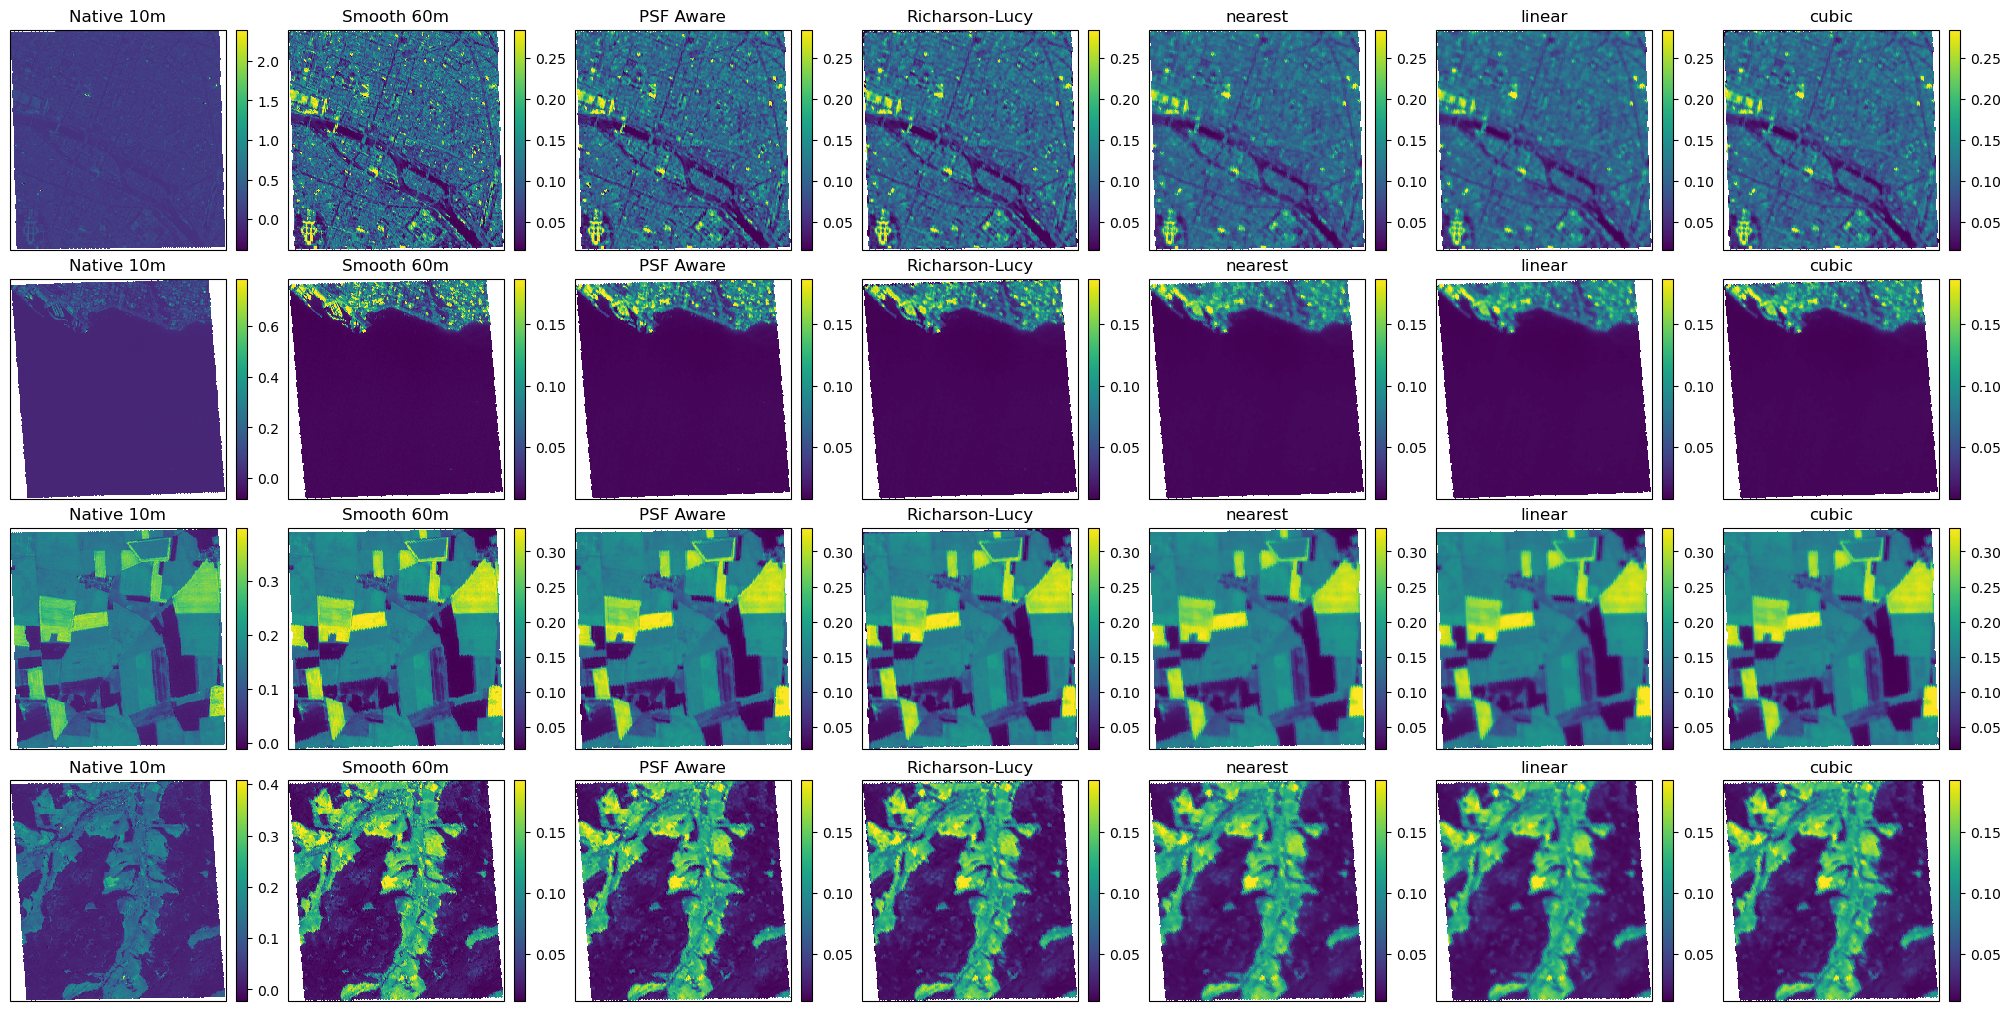

In [9]:
import healpix_plot as hp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

tabscene=['urban','water','agriculture','forest']

# --- figure avec 2 axes côte à côte ---
fig, ax = plt.subplots(
    4, 7,
    subplot_kw={"projection": ccrs.Mollweide()},  # <-- indispensable
    figsize=(20, 10),
    layout="constrained",
)
print(ax.shape)
for l in range(4):
    scene=tabscene[l]
    refs[scene]  # 'cell_ids_native','cell_data_native','cell_ids_ref','cell_data_ref'
    m1 = hp.plot(
        refs[scene]['cell_ids_native'], refs[scene]['cell_data_native'],
        healpix_grid=hp.HealpixGrid(level=20, indexing_scheme="nested"),
        sampling_grid={"shape": 256},ax=ax[l,0],title="Native 10m",colorbar=True,
    )
    m2 = hp.plot(
        refs[scene]['cell_ids_ref'], refs[scene]['cell_data_ref'],
        healpix_grid=hp.HealpixGrid(level=19, indexing_scheme="nested"),
        sampling_grid={"shape": 256},ax=ax[l,1],title="Smooth 60m",colorbar=True,
        vmin= np.quantile(refs[scene]['cell_data_ref'],0.01),
        vmax= np.quantile(refs[scene]['cell_data_ref'],0.99),
    )
    hp.plot(
        psf_results[scene]["cell_ids"], psf_results[scene]["cell_data"],
        healpix_grid=hp.HealpixGrid(level=19, indexing_scheme="nested"),
        sampling_grid={"shape": 256},ax=ax[l,2],title="PSF Aware",colorbar=True,
        vmin= np.quantile(refs[scene]['cell_data_ref'],0.01),
        vmax= np.quantile(refs[scene]['cell_data_ref'],0.99),
    )
    hp.plot(
        rl_results[scene]["cell_ids"], rl_results[scene]["cell_data"],
        healpix_grid=hp.HealpixGrid(level=19, indexing_scheme="nested"),
        sampling_grid={"shape": 256},ax=ax[l,3],title="Richarson-Lucy",colorbar=True,
        vmin= np.quantile(refs[scene]['cell_data_ref'],0.01),
        vmax= np.quantile(refs[scene]['cell_data_ref'],0.99),
    )
    tab=['nearest','linear','cubic']
    for k in range(3):
        m2 = hp.plot(
            classical_results[(scene,tab[k])]['cell_ids'], classical_results[(scene,tab[k])]['cell_data'],
            healpix_grid=hp.HealpixGrid(level=19, indexing_scheme="nested"),
            sampling_grid={"shape": 256},ax=ax[l,4+k],title=tab[k],colorbar=True,
        vmin= np.quantile(refs[scene]['cell_data_ref'],0.01),
        vmax= np.quantile(refs[scene]['cell_data_ref'],0.99),
        )
    
        
    #print(scene, np.std(refs[scene]['cell_data_ref']-psf_results[scene]["cell_data"]),np.std(refs[scene]['cell_data_ref']-rl_results[scene]["cell_data"]),
    #        [np.std(refs[scene]['cell_data_ref']-classical_results[(scene,tab[k])]['cell_data']) for k in range(3)])


## Step 7 -- alignment and metrics, per scene/method

This loop is the transparent, inspectable version of `run_all()` below: every `(scene, method)` pair, the number of cells actually compared after masking, and its metrics, printed as it goes.

In [10]:
rows = []
for scene in gt.benchmark_coordinates:
    ref = refs[scene]
    g = coarse[scene]

    e, t, _ = gt.align_and_mask(psf_results[scene]["cell_ids"], psf_results[scene]["cell_data"], ref, g)
    rows.append(gt.compute_metrics(e, t, scene, "psf_aware"))

    for method in gt.CLASSICAL_METHODS:
        d = classical_results[(scene, method)]
        e, t, _ = gt.align_and_mask(d["cell_ids"], d["cell_data"], ref, g)
        rows.append(gt.compute_metrics(e, t, scene, f"classical_{method}"))

    d = rl_results[scene]
    e, t, _ = gt.align_and_mask(d["cell_ids"], d["cell_data"], ref, g)
    rows.append(gt.compute_metrics(e, t, scene, "richardson_lucy"))

metrics_df = pd.DataFrame(rows)
metrics_df


,scene,method,n_cells,rmse,mae,bias,corr,psnr
0,urban,psf_aware,29910,0.027182,0.017427,3.333886e-05,0.883253,38.193888
1,urban,classical_nearest,29910,0.036431,0.023503,5.635860e-05,0.789654,35.650090
2,urban,classical_linear,29910,0.037736,0.024332,3.971538e-05,0.776326,35.344332
3,urban,classical_cubic,29910,0.035285,0.022723,4.039716e-05,0.807951,35.927645
4,urban,richardson_lucy,29910,0.035386,0.019588,-3.178216e-04,0.798790,35.902761
5,water,psf_aware,29892,0.008972,0.002551,-2.019180e-07,0.956658,34.190455
6,water,classical_nearest,29892,0.011714,0.003307,-8.587856e-06,0.925888,31.873798
7,water,classical_linear,29892,0.012077,0.003429,-1.556301e-05,0.921256,31.609246
8,water,classical_cubic,29892,0.011308,0.003186,-1.055736e-05,0.931283,32.180403
9,water,richardson_lucy,29892,0.010370,0.002821,-8.664537e-05,0.942624,32.932438


## Full run (cached, same result as the step-by-step loop above) + table + figures

In [11]:
metrics_df = gt.run_all(force=False)
gt.format_table(metrics_df)


,Scene,PSF-aware RMSE,PSF-aware Corr,PSF-aware n,Nearest-neighbor RMSE,Nearest-neighbor Corr,Nearest-neighbor n,Bilinear RMSE,Bilinear Corr,Bilinear n,Bicubic RMSE,Bicubic Corr,Bicubic n,Richardson-Lucy RMSE,Richardson-Lucy Corr,Richardson-Lucy n
0,urban,0.027182,0.883253,29910,0.036431,0.789654,29910,0.037736,0.776326,29910,0.035285,0.807951,29910,0.035386,0.798790,29910
1,water,0.008972,0.956658,29892,0.011714,0.925888,29892,0.012077,0.921256,29892,0.011308,0.931283,29892,0.010370,0.942624,29892
2,forest,0.008998,0.987070,29926,0.013697,0.970409,29926,0.014078,0.968975,29926,0.012678,0.974819,29926,0.010551,0.982454,29926
3,agriculture,0.007409,0.995863,29905,0.012604,0.988271,29905,0.012824,0.988023,29905,0.011242,0.990736,29905,0.008511,0.994579,29905


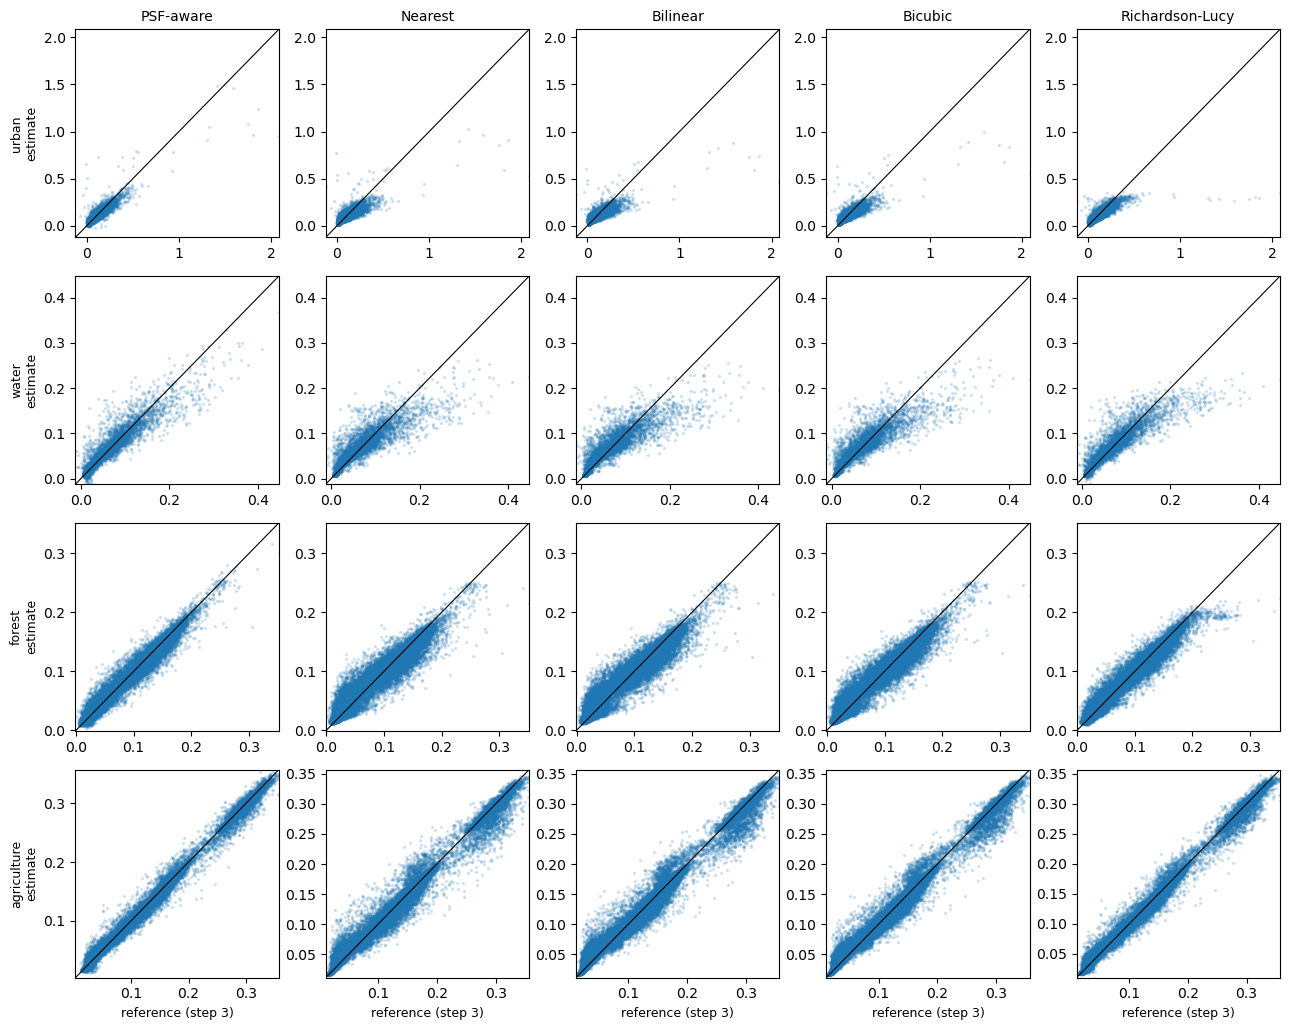

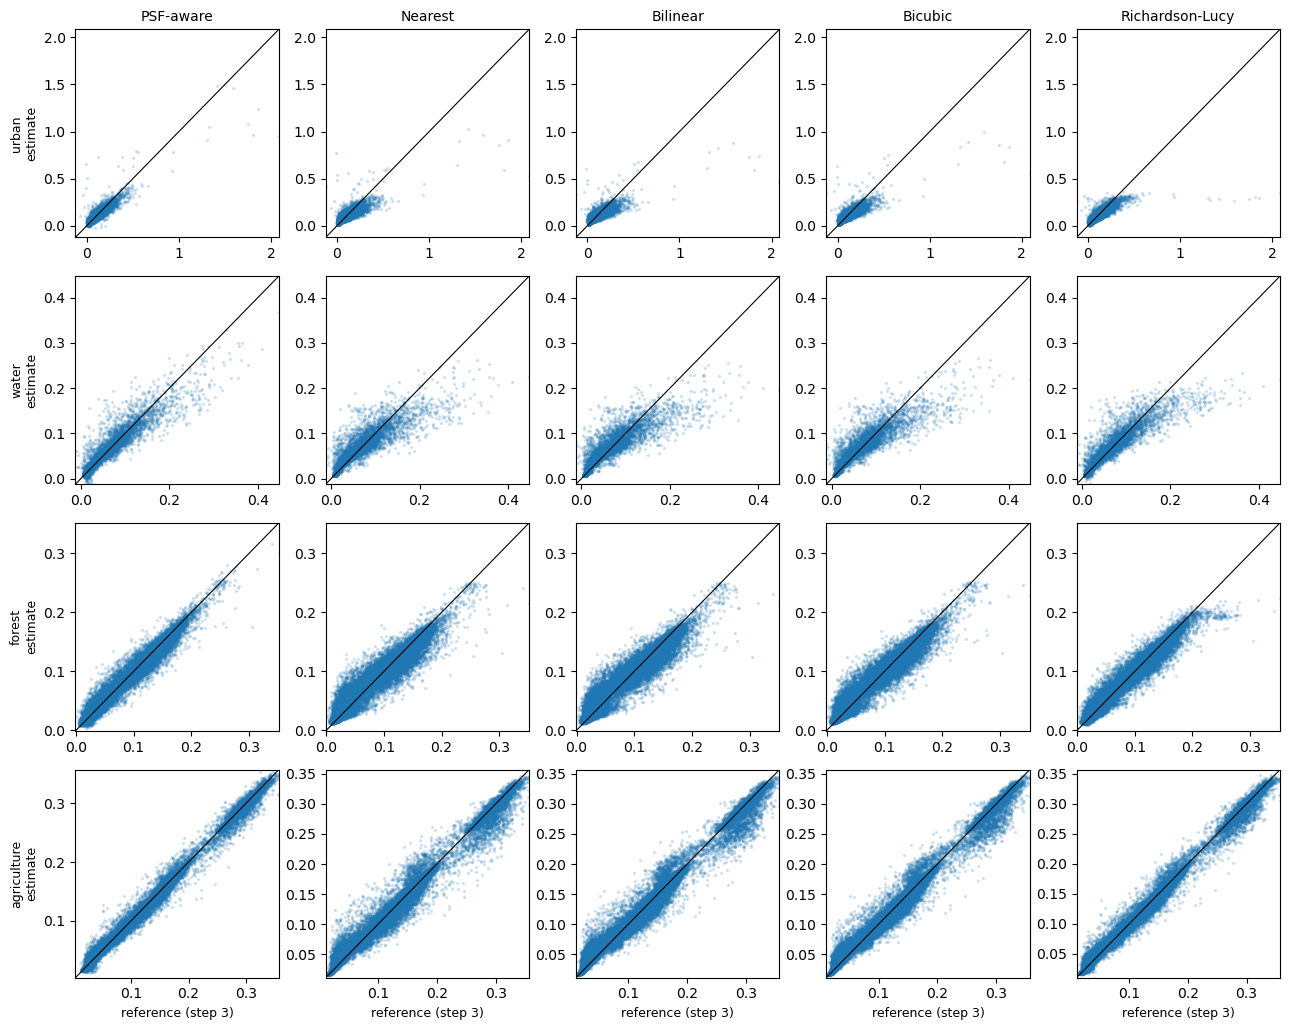

In [12]:
gt.plot_scatter(force=False)


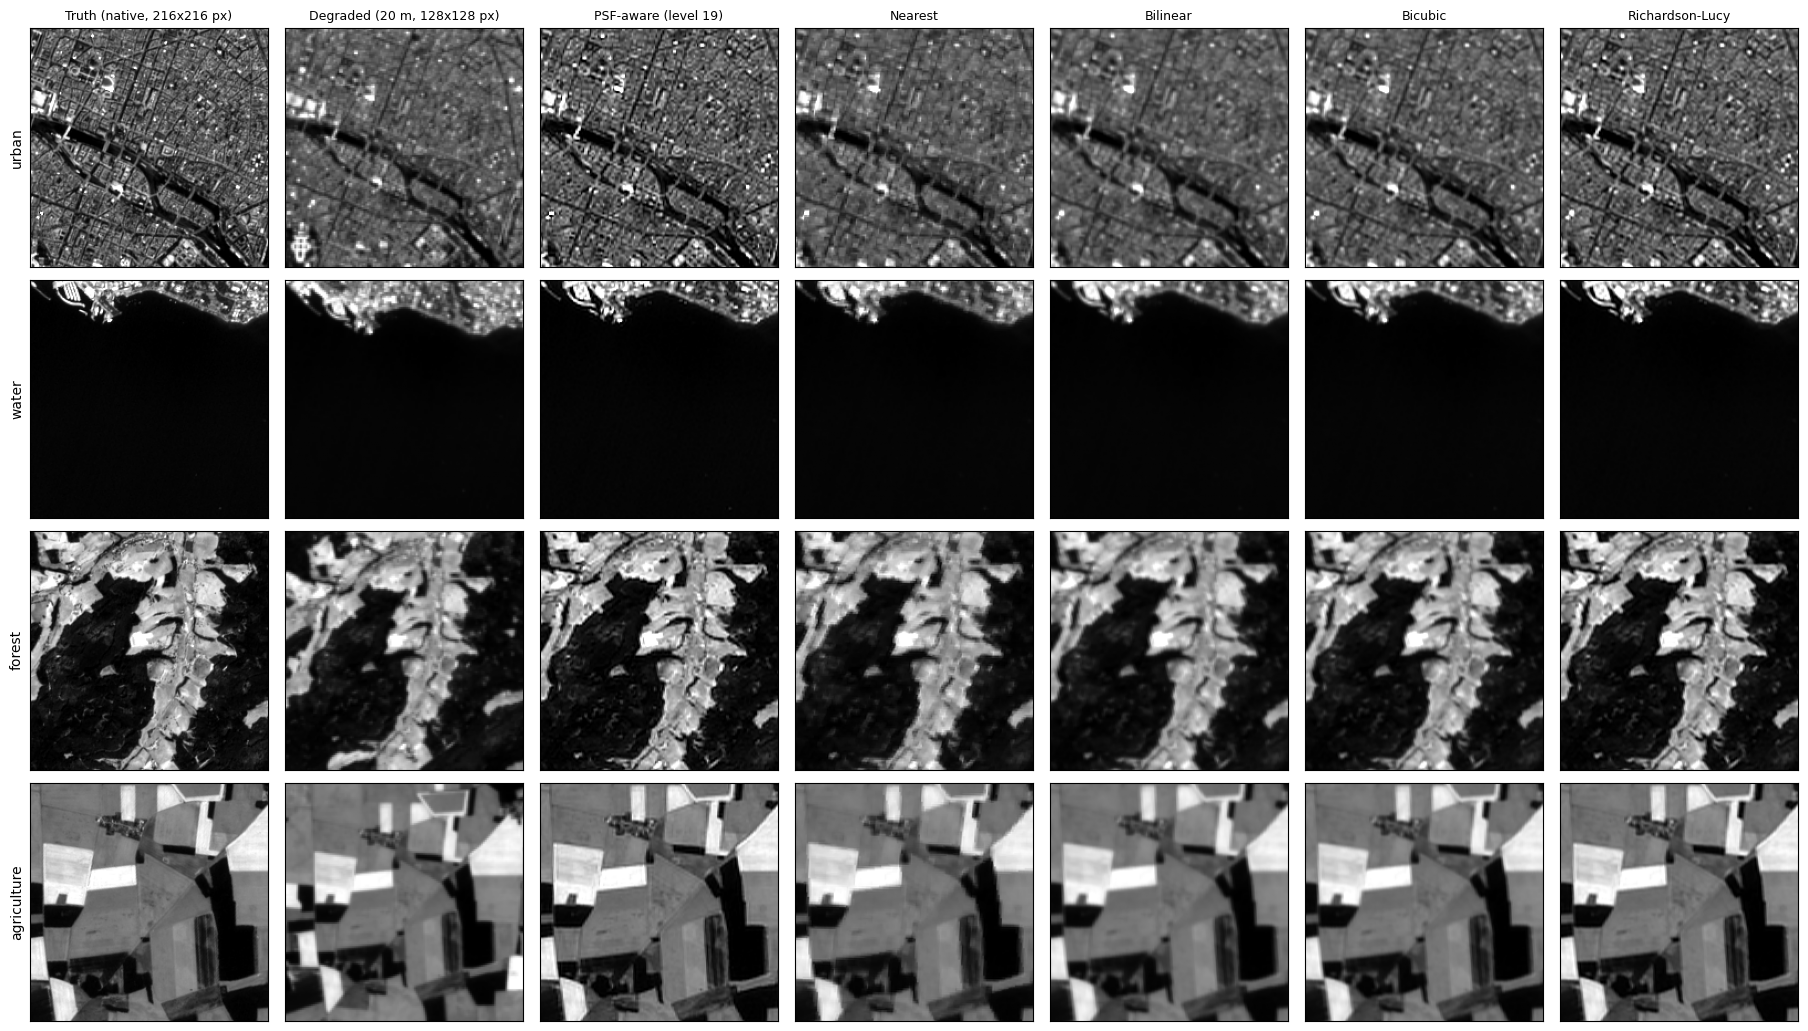

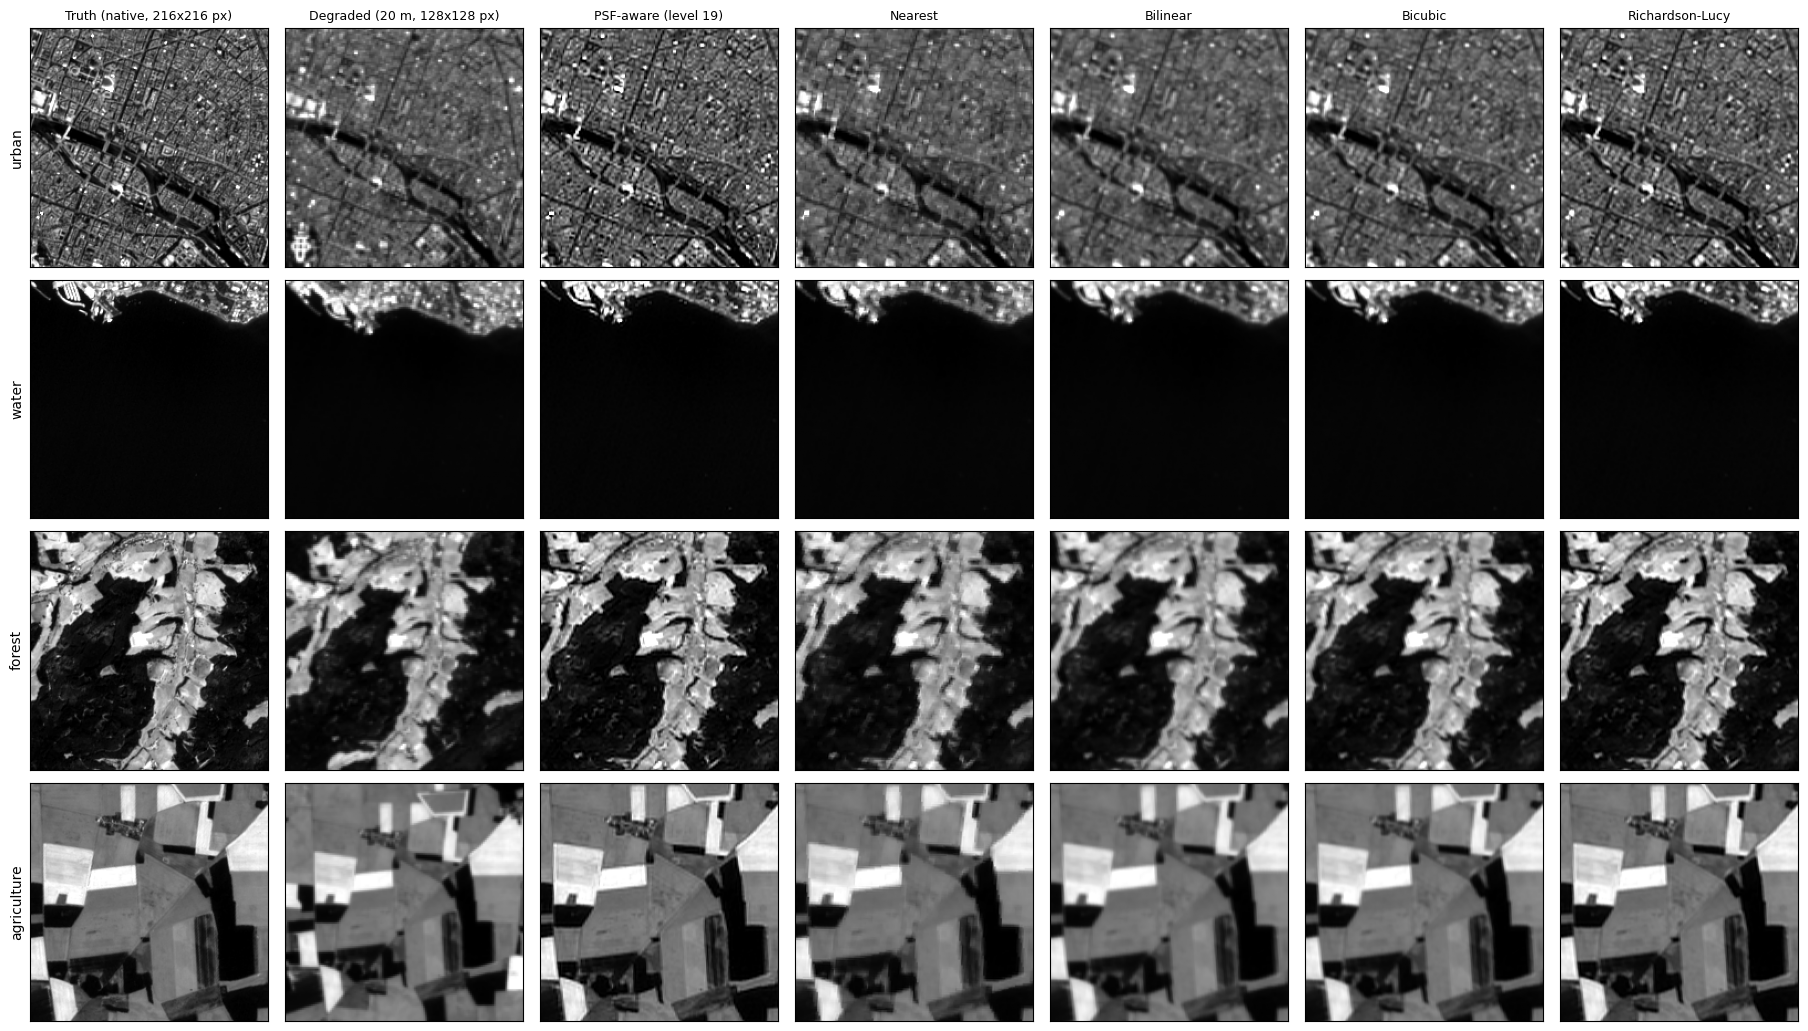

In [13]:
gt.plot_panels(force=False)


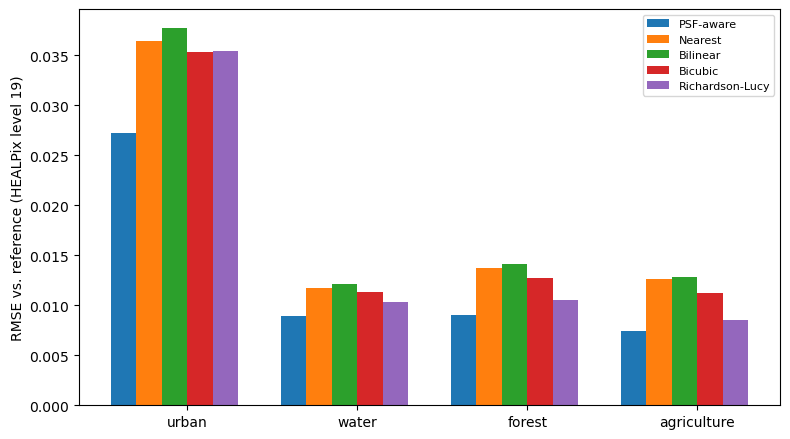

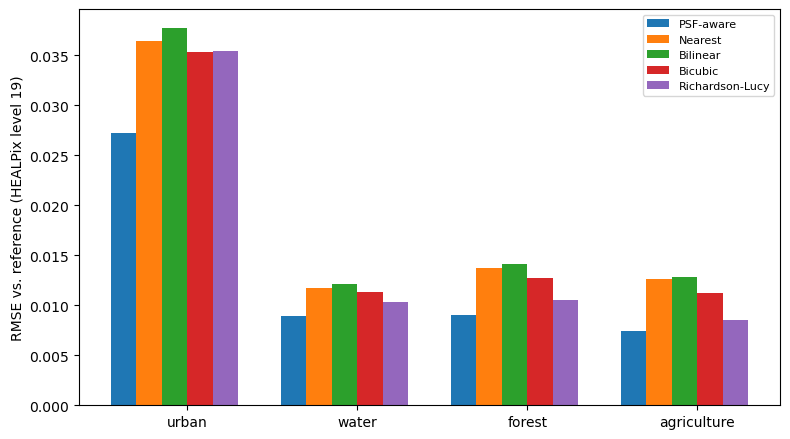

In [14]:
gt.plot_rmse_summary(metrics_df)


## Control experiments

Two known asymmetries of the protocol, each isolated by re-running the whole
thing under one changed setting. Cache filenames encode every setting, so
these never collide with the main run above.

**A. Shared estimator.** Steps 2-3 build the reference with the same
`PSFResampler` family that step 6 applies. A systematic signature of that
operator would show up in the reference *and* in the PSF-aware estimate, but
not in the baselines. `reference_mode="geometric"` rebuilds the reference by
direct pixel aggregation, no spatial-response model anywhere.

Absolute RMSE is **not** comparable between the two reference modes -- the
geometric reference targets the observed field, still carrying the sensor's
own ~12.5 m response, rather than the latent one. What matters is whether the
**ranking** survives.

In [15]:
df_main = gt.run_all(force=False)
df_geom = gt.run_variant(reference_mode="geometric", label="geometric ref")

print("ranking, default (PSF-aware) reference:")
display(gt.rank_table(df_main))
print("ranking, geometric control reference:")
display(gt.rank_table(df_geom))


ranking, default (PSF-aware) reference:


scene,agriculture,forest,urban,water
method,,,,
classical_cubic,3.0,3.0,2.0,3.0
classical_linear,5.0,5.0,5.0,5.0
classical_nearest,4.0,4.0,4.0,4.0
psf_aware,1.0,1.0,1.0,1.0
richardson_lucy,2.0,2.0,3.0,2.0


ranking, geometric control reference:


scene,agriculture,forest,urban,water
method,,,,
classical_cubic,3.0,3.0,2.0,3.0
classical_linear,5.0,5.0,5.0,5.0
classical_nearest,4.0,4.0,4.0,4.0
psf_aware,1.0,1.0,1.0,1.0
richardson_lucy,2.0,2.0,3.0,2.0


**B. Baseline estimand.** The reference is a child-cell average; the
raster baselines used to be read out as a single point sample at the cell
centre. `BASELINE_ESTIMAND="cell_average"` (now the default) averages the 4
level-20 child centres instead, putting both sides on the same estimand --
the same correction already applied to Richardson-Lucy in the paper's
synthetic experiment.

In [16]:
df_point = gt.run_variant(baseline_estimand="point_sample", label="point sample")

comp = (df_main.assign(estimand="cell_average")
        .merge(df_point[["scene", "method", "rmse"]], on=["scene", "method"],
               suffixes=("_cell_avg", "_point")))
comp["change_pct"] = 100 * (comp.rmse_point - comp.rmse_cell_avg) / comp.rmse_cell_avg
comp[["scene", "method", "rmse_cell_avg", "rmse_point", "change_pct"]]


,scene,method,rmse_cell_avg,rmse_point,change_pct
0,urban,psf_aware,0.027182,0.027182,0.000005
1,urban,classical_nearest,0.036431,0.036714,0.776257
2,urban,classical_linear,0.037736,0.037167,-1.509626
3,urban,classical_cubic,0.035285,0.034569,-2.028959
4,urban,richardson_lucy,0.035386,0.034790,-1.685141
5,water,psf_aware,0.008972,0.008972,-0.000002
6,water,classical_nearest,0.011714,0.012046,2.831021
7,water,classical_linear,0.012077,0.011928,-1.233628
8,water,classical_cubic,0.011308,0.011112,-1.729523
9,water,richardson_lucy,0.010370,0.010168,-1.945654


## Notes

- All parameters, function bodies, and the full design rationale (why this
  protocol, and why the two earlier ones were revised) live in
  `tests/real_groundtruth_common_tools.py`. This notebook is intentionally
  just calls.
- `force=True` on any `gt.build_*`/`gt.reconstruct_*` call recomputes and
  overwrites that step's cache; every cache filename already embeds
  `NATIVE_LEVEL`/`REF_LEVEL`/`BLOCK`/`RECON_FWHM_M`
  (`gt._cache_suffix()`), so changing those never silently reuses a stale
  result -- `force=False` is only a *speed* choice, not a correctness one.
- `refs`, `coarse`, `psf_results`, `classical_results`, `rl_results` are
  kept as plain dicts in this notebook's namespace specifically so you can
  poke at any intermediate array directly, e.g.
  `refs["urban"]["cell_data_ref"]` or `coarse["forest"]["img_coarse"]`.


## Control C -- anisotropic PSF-shape mismatch

This control changes the imposed 10 m $\rightarrow$ 20 m degradation from the matched isotropic 25 m Gaussian to a strongly anisotropic Gaussian with $\mathrm{FWHM}_x=24$ m and $\mathrm{FWHM}_y=45$ m in projected UTM axes. The released `PSFResampler` interface still reconstructs with one scalar isotropic width (25 m), as does the Richardson--Lucy baseline. The experiment therefore measures robustness to an unmodelled PSF shape; it must not be described as implementation of arbitrary-kernel support. Conceptually, the weighted-adjoint formulation remains valid for any non-negative local response, but exposing and validating such kernels requires a future API extension. The metric margin is increased to eight times the largest imposed width (360 m) to suppress boundary contamination. This control still uses the four cached Sentinel-2 patches; the 40-region Esri experiment in `multi_patch_latitude_validation.ipynb` is a different, synthetic-detector validation.


In [17]:
# ANISOTROPIC_24X45_MARKER
RUN_ANISOTROPIC_24X45 = True

if RUN_ANISOTROPIC_24X45:
    df_anisotropic = gt.run_anisotropic_psf_mismatch(
        force=False, fwhm_x_m=24.0, fwhm_y_m=45.0
    )
    anisotropic_table = gt.format_table(
        df_anisotropic,
        csv_name="real_groundtruth_downscale_anisotropic_24x45_table.csv",
    )
    anisotropic_ranks = gt.rank_table(df_anisotropic)
    df_anisotropic.to_csv(
        gt.TABLE_DIR / "real_groundtruth_downscale_anisotropic_24x45_metrics.csv",
        index=False,
    )
    display(anisotropic_table)
    display(anisotropic_ranks)
else:
    print("Set RUN_ANISOTROPIC_24X45=True to run the PSF-shape mismatch control.")


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 6.377
Itt 4 : 0.07328
Itt 8 : 0.00433
Itt 12 : 0.000374
Final Itt 13 : 0.0001981
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.7881
Itt 4 : 0.00871
Itt 8 : 0.0004529
Itt 12 : 3.607e-05
Final Itt 13 : 1.898e-05
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.7471
Itt 4 : 0.008942
Itt 8 : 0.0004938
Itt 12 : 3.779e-05
Final Itt 13 : 2.002e-05
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.5848
Itt 4 : 0.006061
Itt 8 : 0.0003191
Itt 12 : 2.179e-05
Final Itt 13 : 1.117e-05


,Scene,PSF-aware RMSE,PSF-aware Corr,PSF-aware n,Nearest-neighbor RMSE,Nearest-neighbor Corr,Nearest-neighbor n,Bilinear RMSE,Bilinear Corr,Bilinear n,Bicubic RMSE,Bicubic Corr,Bicubic n,Richardson-Lucy RMSE,Richardson-Lucy Corr,Richardson-Lucy n
0,urban,0.033450,0.811331,21688,0.038859,0.734829,21688,0.039688,0.723272,21688,0.038215,0.747627,21688,0.039331,0.724138,21688
1,water,0.007780,0.908962,21659,0.009001,0.875807,21659,0.009194,0.870064,21659,0.008863,0.880005,21659,0.008283,0.896177,21659
2,forest,0.012686,0.975146,21679,0.015975,0.960496,21679,0.016279,0.959169,21679,0.015274,0.964078,21679,0.013863,0.970533,21679
3,agriculture,0.011010,0.990721,21676,0.014739,0.983494,21676,0.014965,0.983131,21676,0.013785,0.985640,21676,0.011762,0.989443,21676


scene,agriculture,forest,urban,water
method,,,,
classical_cubic,3.0,3.0,2.0,3.0
classical_linear,5.0,5.0,5.0,5.0
classical_nearest,4.0,4.0,3.0,4.0
psf_aware,1.0,1.0,1.0,1.0
richardson_lucy,2.0,2.0,4.0,2.0


### Interpretation boundary

A successful result answers the reviewer request for at least one non-matched PSF *in the real-radiometry downscaling protocol*. It does not demonstrate native anisotropic reconstruction, because generation uses the 24 m $\times$ 45 m response while inversion deliberately retains the currently implemented isotropic 25 m response. Report the matched and anisotropic results side by side and keep this distinction explicit in the manuscript.


## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run, instead of relying on a manual copy that has silently gone stale before.
Assets whose `tex/` copy is newer (hand-maintained figures) are reported and
left alone.

In [ ]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()
